In [1]:
from mphelper import ProcessWrapPool
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
from pathlib import Path
import pybedtools
import pyBigWig
import seaborn as sns
from statannotations.Annotator import Annotator
import numpy as np

In [2]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9
lw = 0.8

In [3]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

# Binary classification at different seq depths

In [4]:
ds = ["distal", "proximal"]
ps = ["divergent", "unidirectional"]
ks = ["pl", "mn"]

In [5]:
samples = [f"{n}M" for n in [1, 5, 10, 20, 30]] + ["Original"]

In [6]:
dfs = {}

In [7]:
# Check the fraction of unidirectional elements at lower seq depth that are classified as divergent, unidirectional, or not found at higher seq depth

for d in ds:
	results = []
	for i in range(len(samples)-1):
		s1, s2 = samples[i], samples[i+1]
		b1 = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_pd/C1_{s1}_unidirectional_{d}.bed")
		if s2 != "Original":
			bs = [pybedtools.BedTool(f"{PROJECT_DIR_d}bed_pd/C1_{s2}_{p}_{d}.bed") for p in ps]
		else:
			bs = [pybedtools.BedTool(f"{PROJECT_DIR_d}bed_pd/C1_{p}_{d}.bed") for p in ps]
		# Re-classified as divergent
		overlaps_di = set(["_".join(i.fields[:3]) for i in b1.intersect(bs[0], u=True)])
		ratio_di = round(len(overlaps_di)/len(b1),2)
		# Remain as unidirectional
		overlaps_uni = set(["_".join(i.fields[:3]) for i in b1.intersect(bs[1], u=True) if "_".join(i.fields[:3]) not in overlaps_di])	
		ratio_uni = round(len(overlaps_uni)/len(b1),2)
		# Not found
		ratio_none = 1-ratio_di-ratio_uni
		results.append([f"{s1} \u2192 {s2}", ratio_di, ratio_uni, ratio_none])
	dfs[("low2high", d)] = pd.DataFrame(results, columns=["Pair", "Divergent", "Unidirectional", "Not found"]).iloc[::-1]

In [8]:
# Check the fraction of divergent elements at higher seq depth that are classified as divergent, unidirectional, or not found at lower seq depth

new_labels = defaultdict(dict)
for d in ds:
	results = []
	for i in range(len(samples)-1):
		s1, s2 = samples[::-1][i], samples[::-1][i+1]
		if s1 != "Original":
			b1 = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_pd/C1_{s1}_divergent_{d}.bed")
		else:
			b1 = pybedtools.BedTool(f"{PROJECT_DIR_d}bed_pd/C1_divergent_{d}.bed")
		bs = [pybedtools.BedTool(f"{PROJECT_DIR_d}bed_pd/C1_{s2}_{p}_{d}.bed") for p in ps]
		# Re-classified as unidirectional
		overlaps_uni = set(["_".join(i.fields[:3]) for i in b1.intersect(bs[1], u=True)])
		new_labels[(s1,s2,d)]["Unidirectional"] = overlaps_uni
		ratio_uni = round(len(overlaps_uni)/len(b1),2)
		# Remain as divergent
		overlaps_di = set(["_".join(i.fields[:3]) for i in b1.intersect(bs[0], u=True) if "_".join(i.fields[:3]) not in overlaps_uni])	
		new_labels[(s1,s2,d)]["Divergent"] = overlaps_di
		ratio_di = round(len(overlaps_di)/len(b1),2)
		# Not found
		new_labels[(s1,s2,d)]["Not found"] = ["_".join(i.fields[:3]) for i in b1 if "_".join(i.fields[:3]) not in overlaps_uni and "_".join(i.fields[:3]) not in overlaps_di]
		ratio_none = 1-ratio_di-ratio_uni
		results.append([f"{s1} \u2192 {s2}", ratio_di, ratio_uni, ratio_none])
	dfs["high2low", d] = pd.DataFrame(results, columns=["Pair", "Divergent", "Unidirectional", "Not found"])

In [9]:
# Source data for SuppFig. 5a & b and SuppFig. 6a & b

for k, d in dfs:
	figN = "SuppFig5" if d == "distal" else "SuppFig6"
	alphabet = "a" if k == "low2high" else "b"
	dfs[k,d].to_csv(f"{PROJECT_DIR_o}source_data/{figN}{alphabet}/{k}_{d}_fraction.txt", sep="\t", index=False)

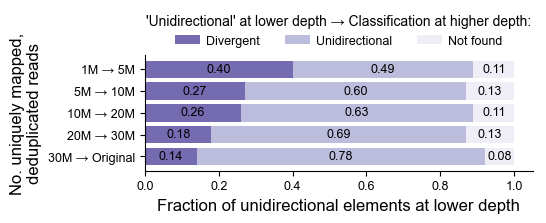

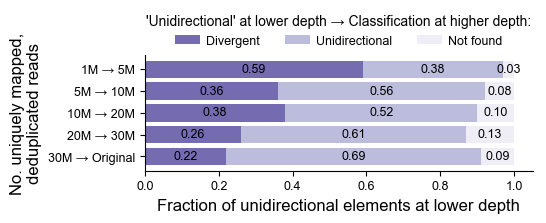

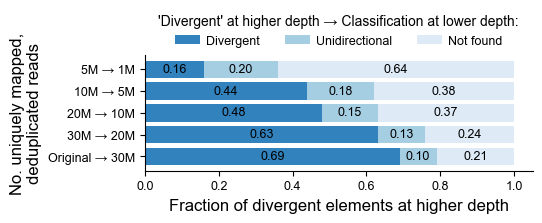

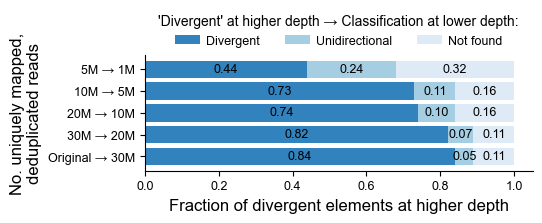

In [10]:
for k, d in itertools.product(["low2high", "high2low"], ds):
	palette = ["#756bb1", "#bcbddc", "#efedf5"] if k == "low2high" else ["#3182bd", "#a6cee3", "#deebf7"]
	ax = dfs[(k,d)].set_index("Pair").plot(kind="barh", stacked=True, color=palette, width=0.8, figsize=(5, 1.5))
	ax.spines[["right", "top"]].set_visible(False)
	
	for p in ax.patches:
		width, height = p.get_width(), p.get_height()
		x, y = p.get_xy() 
		ax.text(x+width/2, 
				y+height/2, 
				f"{width:.2f}", 
				fontsize=sfontsize,
				ha="center", 
				va="center")
	
	ax.set_ylabel("No. uniquely mapped,\ndeduplicated reads", fontsize=bfontsize)
	ax.set_yticks(ax.get_yticks())
	ax.tick_params(labelsize=sfontsize)

	xlabel = "Fraction of unidirectional elements at lower depth" if k == "low2high" else "Fraction of divergent elements at higher depth"
	ax.set_xlabel(xlabel, fontsize=bfontsize)
	handles, labels = ax.get_legend_handles_labels()
	title = "'Unidirectional' at lower depth \u2192 Classification at higher depth:" if k == "low2high" else "'Divergent' at higher depth \u2192 Classification at lower depth:"
	ax.legend(handles, labels, 
			  loc="upper center", bbox_to_anchor=(0.5, 1.45), 
			  handletextpad=0.5, title=title,
			  ncol=3, fontsize=sfontsize, frameon=False)

	figN = "SuppFig5" if d == "distal" else "SuppFig6"
	alphabet = "a" if k == "low2high" else "b"
	outputfile = f"{PROJECT_DIR_o}figures/{figN}{alphabet}.png"
	plt.savefig(outputfile, bbox_inches="tight", transparent=True, dpi=300)

# Factors affecting re-classification

In [11]:
# Get total counts and DI at divergent elements in different seq depths

def get_features(bed, bws, outputfile):
	b = pybedtools.BedTool(bed)
	bw1, bw2 = [pyBigWig.open(bw) for bw in bws]

	results = []
	for i in b:
		chrom, start, end = i.fields[:3]
		start = int(start)
		end = int(end)
		reads1 = 0
		reads2 = 0
		# pyBigWig: 0-based start, 0-based end; the end is not included
		if bw1.intervals(chrom, start, end+1) != None:
			for start2, end2, score in bw1.intervals(chrom, start, end+1):
				l = min(end+1, end2) - max(start, start2)
				reads1 += abs(score) * l
		if bw2.intervals(chrom, start, end+1) != None:
			for start2, end2, score in bw2.intervals(chrom, start, end+1):
				l = min(end+1, end2) - max(start, start2)
				reads2 += abs(score) * l

		results.append(["_".join(i.fields[:3]), reads1, reads2, reads1+reads2, (reads1-reads2)/(reads1+reads2)])
		
	df = pd.DataFrame(results, columns=["element", "counts_fwd", "counts_rev", "total_counts", "DI"])
	df.to_csv(outputfile, sep="\t", index=False)

In [17]:
# Source data for Fig. 5c & d and Fig. 6c & d

pwpool = ProcessWrapPool(10)

p = "divergent"
for s, d in itertools.product(samples[1:], ds):
	if s != "Original":
		bed = f"{PROJECT_DIR_d}bed_pd/C1_{s}_{p}_{d}.bed"
		bws = [f"{PROJECT_DIR_d}Analysis/C1_{s}_5{k}.bw" for k in ks]
	else:
		bed = f"{PROJECT_DIR_d}bed_pd/C1_{p}_{d}.bed"
		bws = [f"{PROJECT_DIR_d}Alignments/brm_C1a_and_C1b_erm_5{k}.bw" for k in ks]
	figN = "SuppFig5cd" if d == "distal" else "SuppFig6cd"
	outputfile = f"{PROJECT_DIR_o}source_data/{figN}/C1_{s}_{p}_{d}_counts_DI.text"
	pwpool.run(get_features, args=[bed, bws, outputfile])

In [19]:
len(pwpool.finished_tasks)

10

In [20]:
pwpool.close()

In [21]:
features = defaultdict(dict)
for s, d in itertools.product(samples[1:], ds):
	figN = "SuppFig5cd" if d == "distal" else "SuppFig6cd"
	df = pd.read_table(f"{PROJECT_DIR_o}source_data/{figN}/C1_{s}_{p}_{d}_counts_DI.text")
	for _, row in df.iterrows():
		features[(s,d)][row["element"]] = row["total_counts"], abs(row["DI"])

In [22]:
results = []
for d in ds:
	for i in range(len(samples)-1):
		s1, s2 = samples[::-1][i], samples[::-1][i+1]
		for e in features[(s1,d)]:
			for label in new_labels[(s1,s2,d)]:
				if e in new_labels[(s1,s2,d)][label]:
					break
			results.append([d, f"{s1} \u2192 {s2}", np.log2(features[(s1,d)][e][0]), features[(s1,d)][e][1], label])
df_features = pd.DataFrame(results, columns=["group", "pair", "counts", "DI", "label"])

In [44]:
def plot_features(d, feature, ylabel, legend_y, outputfile):
	df = df_features[df_features["group"]==d]
	fig, ax = plt.subplots(figsize=(13,2.5))

	order = []
	pairs = []
	for i in range(len(samples)-1):
		s1, s2 = samples[::-1][i], samples[::-1][i+1]
		order.append(f"{s1} \u2192 {s2}")
		pairs.extend([
					  ((f"{s1} \u2192 {s2}", "Unidirectional"), (f"{s1} \u2192 {s2}", "Not found")),
					  ((f"{s1} \u2192 {s2}", "Divergent"), (f"{s1} \u2192 {s2}", "Unidirectional"))
					 ])

	hue_plot_params = {"data": df,
					"x": "pair",
					"y": feature,
					"order": order[::-1],  
					"cut": 0,
					"hue": "label",
					"hue_order": ["Divergent", "Unidirectional", "Not found"],
					"palette": ["#3182bd", "#a6cee3", "#deebf7"],
					"linewidth": lw
					}
	g = sns.violinplot(ax=ax, **hue_plot_params)
	g.spines[["top", "right"]].set_visible(False)
	g.set_xlabel("")
	g.set_ylabel(ylabel, fontsize=bfontsize)
	if feature == "DI":
		yticks = [0.2*n for n in range(6)]
	else:
		yticks = [4,8,12] if d == "distal" else [5,10,15]
	g.set_yticks(yticks)

	g.tick_params(axis="x", labelsize=bfontsize)
	g.tick_params(axis="y", labelsize=sfontsize)
	g.legend(loc="upper center", bbox_to_anchor=(0.5,legend_y), frameon=False, ncols=3, title="'Divergent' at higher depth \u2192 Classification at lower depth:", fontsize=sfontsize)
	
	annotator = Annotator(g, pairs, **hue_plot_params)
	annotator.configure(test="Mann-Whitney", comparisons_correction="BH", text_format="full", show_test_name=False, verbose=False, line_width=lw)
	_, results = annotator.apply_and_annotate()

	plt.savefig(outputfile, bbox_inches="tight", transparent=True)

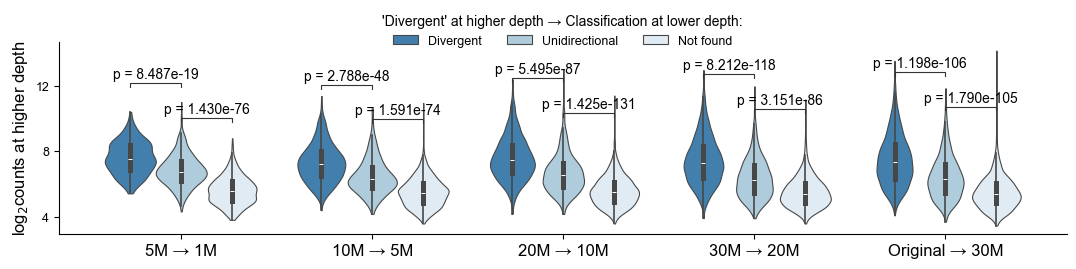

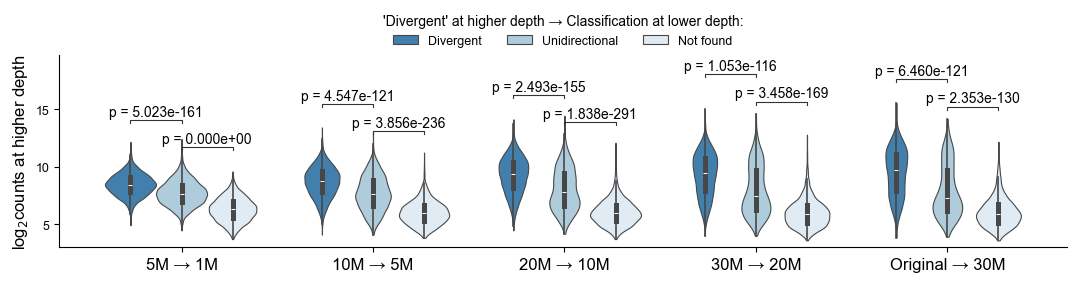

In [45]:
# Transcritpion level

for d in ds:
	figN = "SuppFig5" if d == "distal" else "SuppFig6"
	outputfile = f"{PROJECT_DIR_o}figures/{figN}c.pdf"
	legend_y = 1.2 if d == "distal" else 1.27
	plot_features(d, "counts", "log$_2$counts at higher depth", legend_y, outputfile)

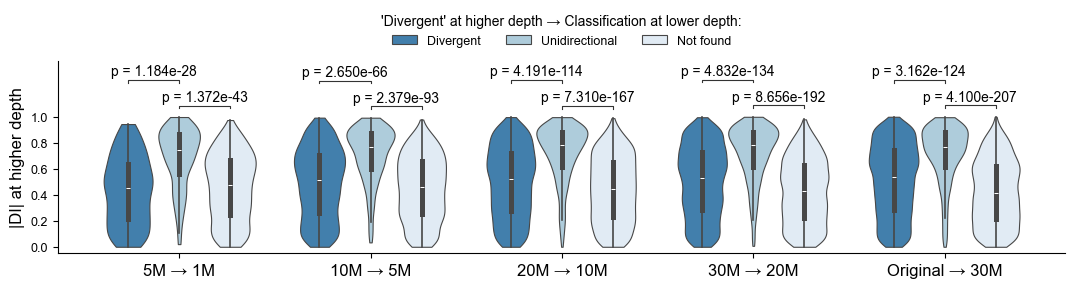

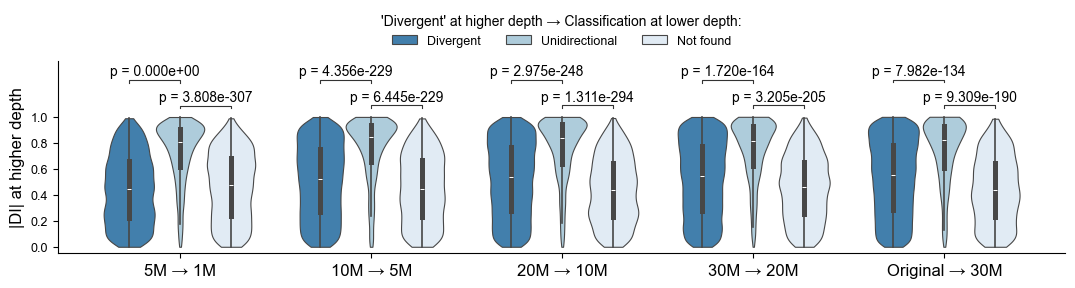

In [46]:
# Absolute DI

for d in ds:
	figN = "SuppFig5" if d == "distal" else "SuppFig6"
	outputfile = f"{PROJECT_DIR_o}figures/{figN}d.pdf"
	plot_features(d, "DI", "|DI| at higher depth", 1.3, outputfile)